In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv('Diwali Sales Data.csv', encoding='unicode_escape')

# Drop fully empty columns
df.drop(columns=['Status', 'unnamed1'], inplace=True)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (11251, 13)


In [3]:
# First 5 rows
print(" First 5 Rows:")
df.head()

 First 5 Rows:


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhraï¿½Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [4]:
# Last 5 rows
print(" Last 5 Rows:")
df.tail()

 Last 5 Rows:


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0
11250,1002744,Brumley,P00281742,F,18-25,19,0,Maharashtra,Western,Healthcare,Office,3,188.0


In [5]:
# Dataset shape
print(f" Dataset Shape: {df.shape[0]} rows  {df.shape[1]} columns")

 Dataset Shape: 11251 rows  13 columns


In [6]:
# Column names
print("Column Names:")
for col in df.columns:
    print(f"  - {col}")

Column Names:
  - User_ID
  - Cust_name
  - Product_ID
  - Gender
  - Age Group
  - Age
  - Marital_Status
  - State
  - Zone
  - Occupation
  - Product_Category
  - Orders
  - Amount


In [7]:
# Confirm data types
print(" Column Data Types:\n")
print(df.dtypes)

 Column Data Types:

User_ID               int64
Cust_name            object
Product_ID           object
Gender               object
Age Group            object
Age                   int64
Marital_Status        int64
State                object
Zone                 object
Occupation           object
Product_Category     object
Orders                int64
Amount              float64
dtype: object


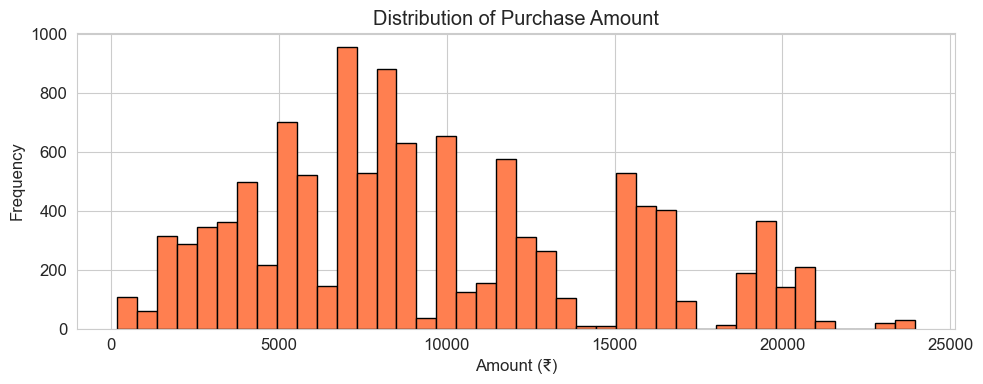

In [8]:
# EDA exploratery data analysis
# univariate analysis
# Histogram of Amount
plt.figure(figsize=(10, 4))
plt.hist(df['Amount'].dropna(), bins=40, color='coral', edgecolor='black')
plt.title('Distribution of Purchase Amount')
plt.xlabel('Amount (₹)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

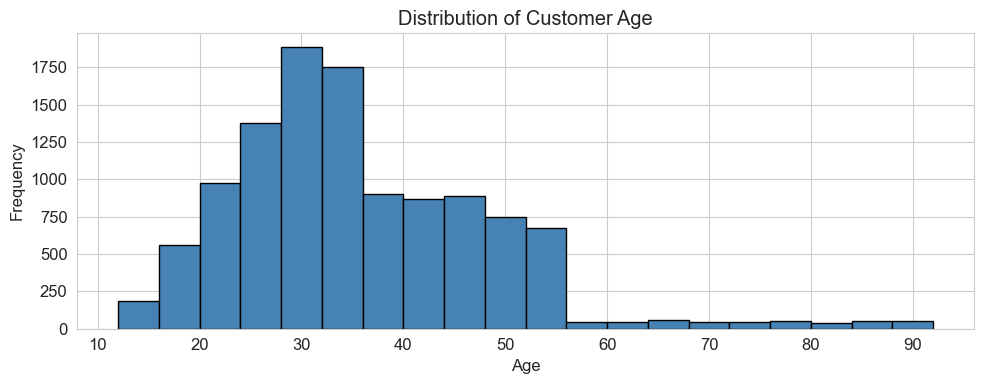

In [9]:
# Histogram of Age
plt.figure(figsize=(10, 4))
plt.hist(df['Age'].dropna(), bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

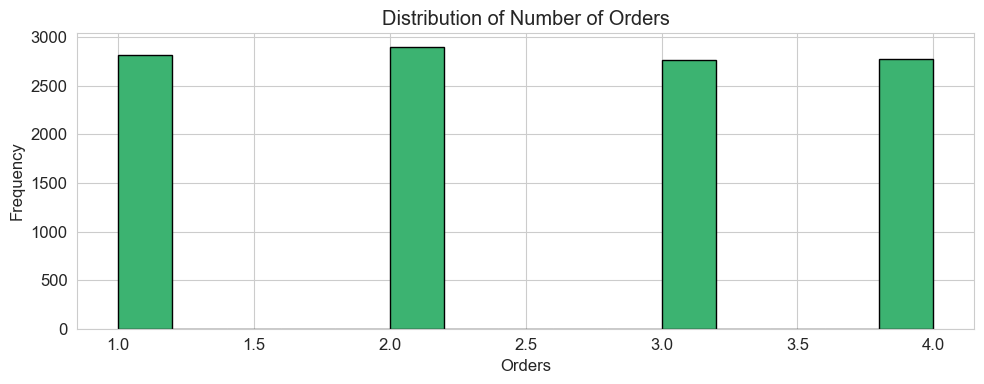

In [10]:
# Histogram of Orders
plt.figure(figsize=(10, 4))
plt.hist(df['Orders'].dropna(), bins=15, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Number of Orders')
plt.xlabel('Orders')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

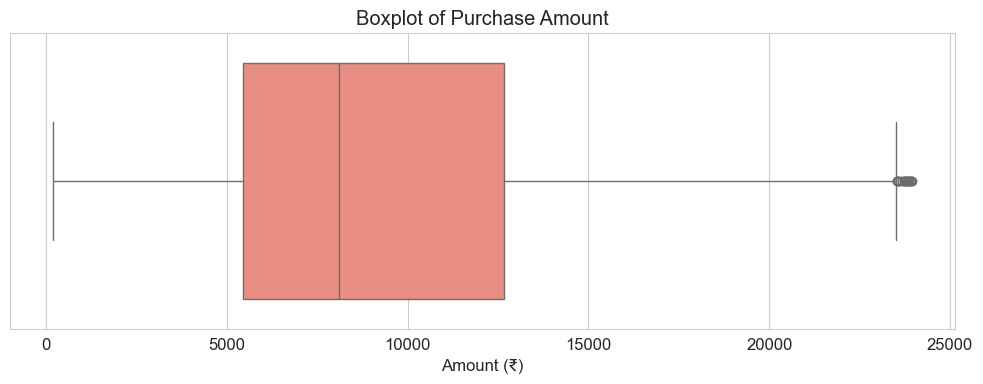

In [11]:
# Boxplot of Amount
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Amount'], color='salmon')
plt.title('Boxplot of Purchase Amount')
plt.xlabel('Amount (₹)')
plt.tight_layout()
plt.show()

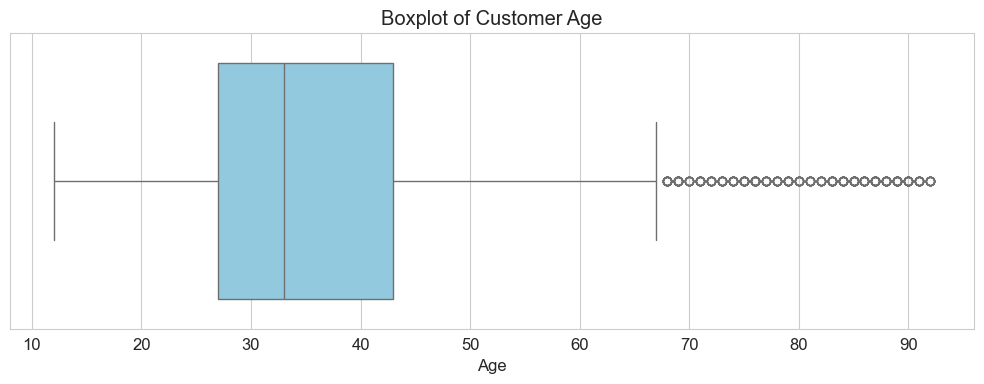

In [12]:
# Boxplot of Age
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Age'], color='skyblue')
plt.title('Boxplot of Customer Age')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

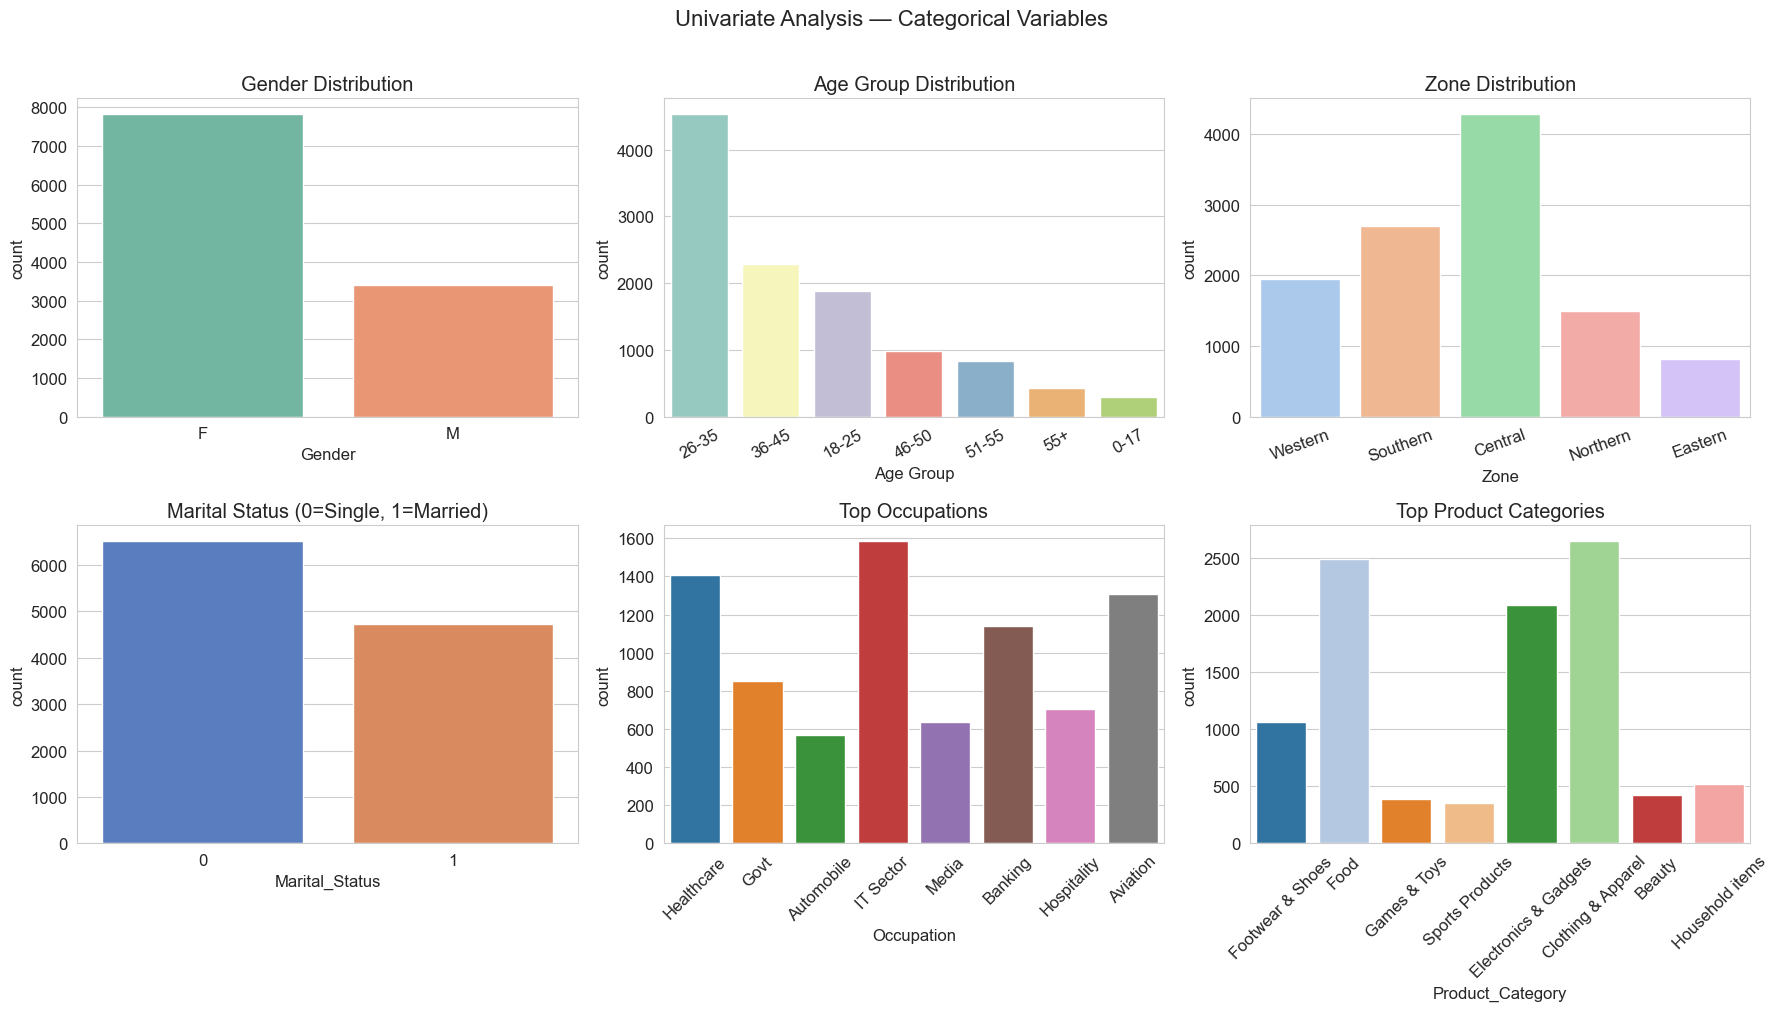

In [13]:
# Count plots for categorical variables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(data=df, x='Gender', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Gender Distribution')

sns.countplot(data=df, x='Age Group', ax=axes[0,1], palette='Set3', order=df['Age Group'].value_counts().index)
axes[0,1].set_title('Age Group Distribution')
axes[0,1].tick_params(axis='x', rotation=30)

sns.countplot(data=df, x='Zone', ax=axes[0,2], palette='pastel')
axes[0,2].set_title('Zone Distribution')
axes[0,2].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x='Marital_Status', ax=axes[1,0], palette='muted')
axes[1,0].set_title('Marital Status (0=Single, 1=Married)')

top_occ = df['Occupation'].value_counts().head(8).index
sns.countplot(data=df[df['Occupation'].isin(top_occ)], x='Occupation', ax=axes[1,1], palette='tab10')
axes[1,1].set_title('Top Occupations')
axes[1,1].tick_params(axis='x', rotation=45)

top_cat = df['Product_Category'].value_counts().head(8).index
sns.countplot(data=df[df['Product_Category'].isin(top_cat)], x='Product_Category', ax=axes[1,2], palette='tab20')
axes[1,2].set_title('Top Product Categories')
axes[1,2].tick_params(axis='x', rotation=45)

plt.suptitle('Univariate Analysis — Categorical Variables', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

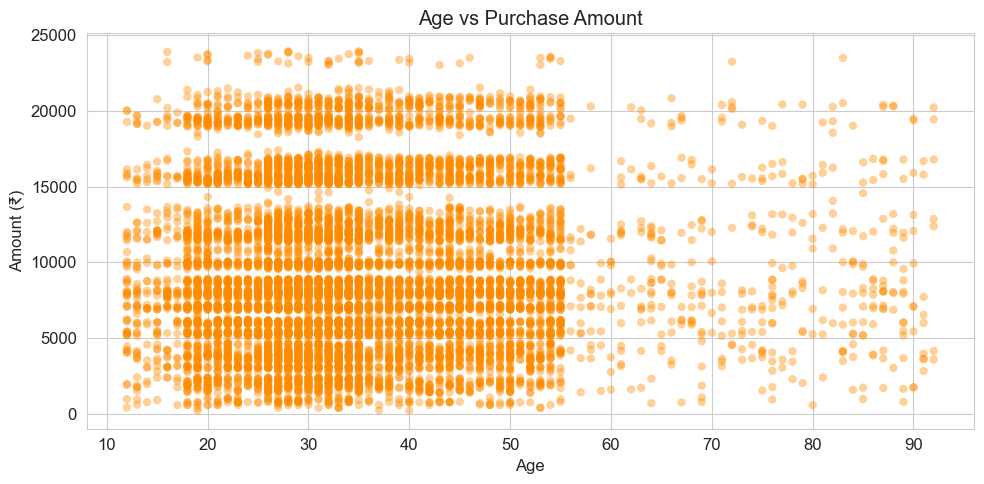

In [14]:
#bivariate analysis
# Amount vs Age (Scatter)
plt.figure(figsize=(10, 5))
plt.scatter(df['Age'], df['Amount'], alpha=0.4, color='darkorange', edgecolors='none')
plt.title('Age vs Purchase Amount')
plt.xlabel('Age')
plt.ylabel('Amount (₹)')
plt.tight_layout()
plt.show()

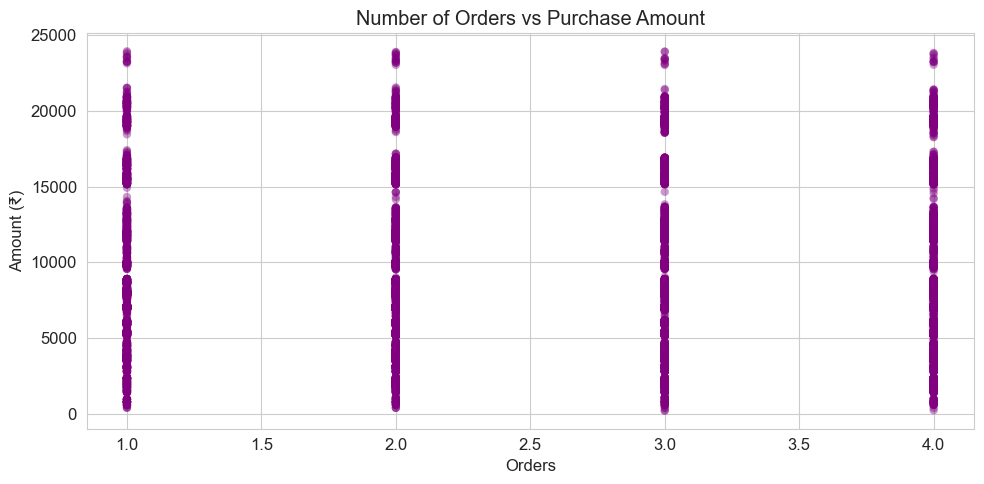

In [15]:
# Amount vs Orders (Scatter)
plt.figure(figsize=(10, 5))
plt.scatter(df['Orders'], df['Amount'], alpha=0.4, color='purple', edgecolors='none')
plt.title('Number of Orders vs Purchase Amount')
plt.xlabel('Orders')
plt.ylabel('Amount (₹)')
plt.tight_layout()
plt.show()

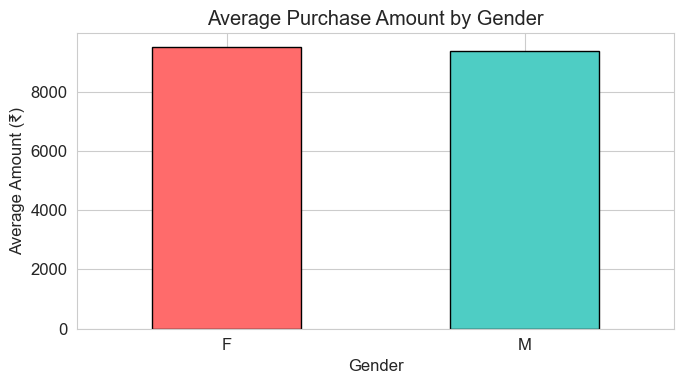

In [16]:
# Average Amount by Gender
plt.figure(figsize=(7, 4))
df.groupby('Gender')['Amount'].mean().plot(kind='bar', color=['#FF6B6B','#4ECDC4'], edgecolor='black')
plt.title('Average Purchase Amount by Gender')
plt.ylabel('Average Amount (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

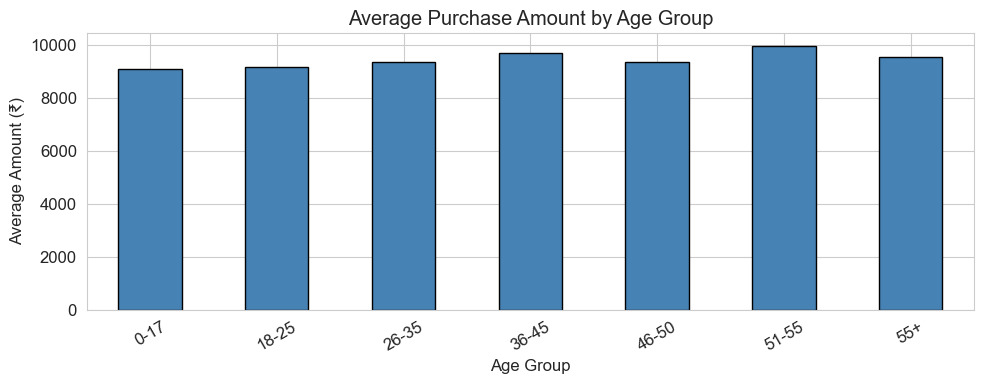

In [17]:
# Average Amount by Age Group
plt.figure(figsize=(10, 4))
age_order = ['0-17','18-25','26-35','36-45','46-50','51-55','55+']
df.groupby('Age Group')['Amount'].mean().reindex(age_order).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Purchase Amount by Age Group')
plt.ylabel('Average Amount (₹)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

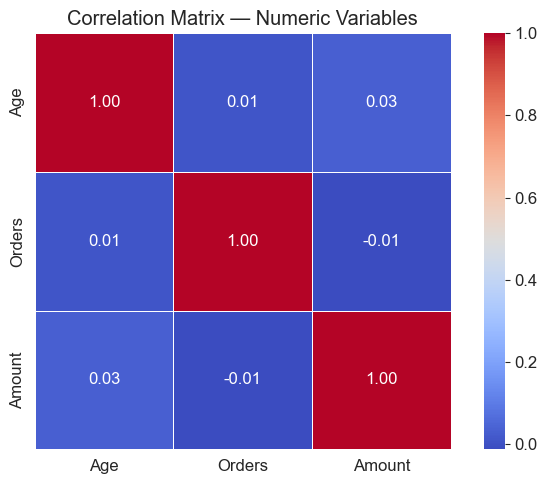

             Age    Orders    Amount
Age     1.000000  0.008090  0.030941
Orders  0.008090  1.000000 -0.013183
Amount  0.030941 -0.013183  1.000000


In [18]:
# Correlation Matrix (Numeric Columns)
num_cols = df[['Age', 'Orders', 'Amount']].dropna()
corr = num_cols.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numeric Variables')
plt.tight_layout()
plt.show()
print(corr)

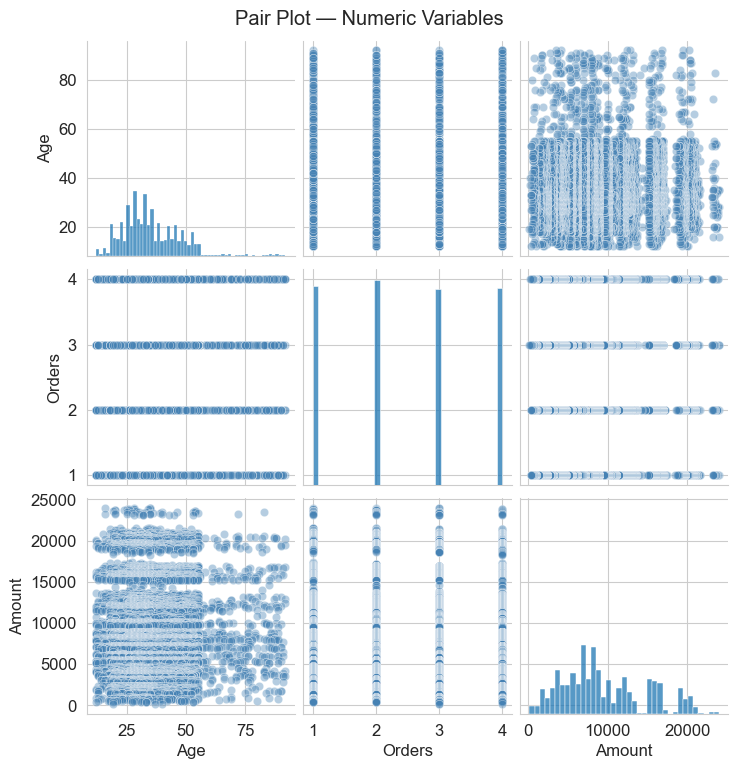

In [19]:
# multivariate analysis
# Pair Plot
pair_df = df[['Age', 'Orders', 'Amount']].dropna()
sns.pairplot(pair_df, diag_kind='hist', plot_kws={'alpha': 0.4, 'color': 'steelblue'})
plt.suptitle('Pair Plot — Numeric Variables', y=1.02)
plt.show()

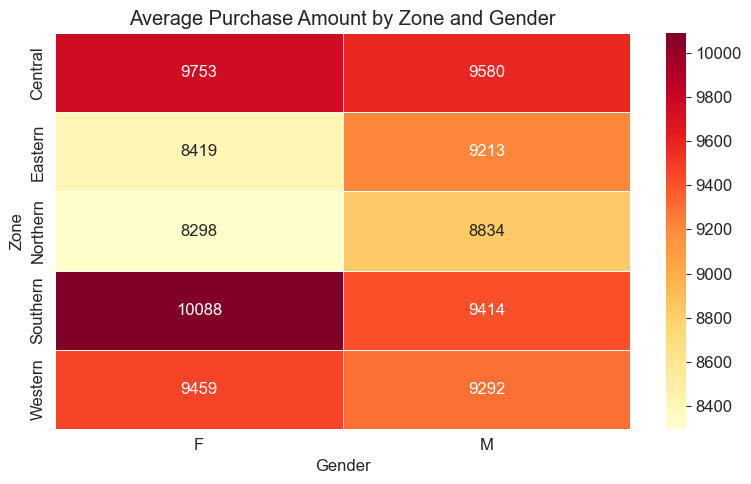

In [20]:
# Heatmap: Average Amount by Zone and Gender
pivot = df.pivot_table(values='Amount', index='Zone', columns='Gender', aggfunc='mean')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Purchase Amount by Zone and Gender')
plt.tight_layout()
plt.show()

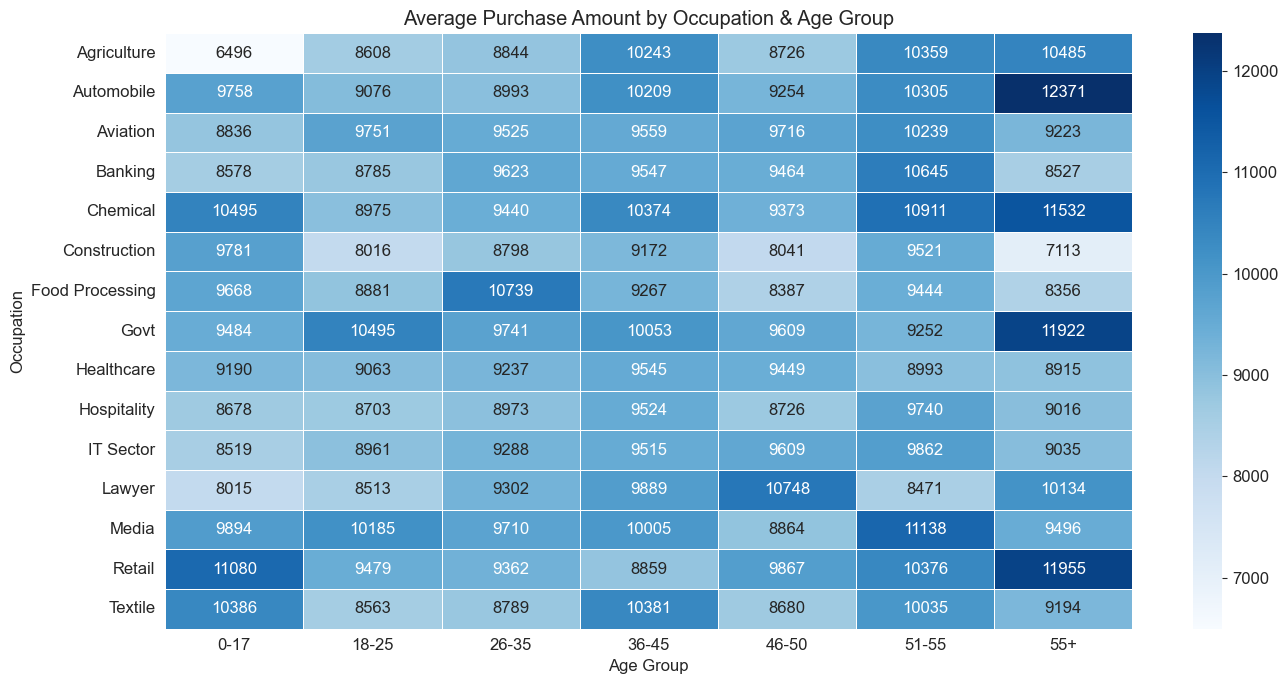

In [21]:
# Heatmap: Average Amount by Occupation and Age Group
pivot2 = df.pivot_table(values='Amount', index='Occupation', columns='Age Group', aggfunc='mean')
plt.figure(figsize=(14, 7))
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5)
plt.title('Average Purchase Amount by Occupation & Age Group')
plt.tight_layout()
plt.show()

In [22]:
# handling missing data and outliers
## Task 3: Handling Missing Data and Outliers
print(" Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

 Missing Values per Column:
User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

Total missing values: 12


In [23]:
# Handle missing values in 'Amount' using Median (robust to outliers)
median_amount = df['Amount'].median()
df['Amount'].fillna(median_amount, inplace=True)
print(f"Missing 'Amount' values filled with median: ₹{median_amount:.2f}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Missing 'Amount' values filled with median: ₹8109.00
Remaining missing values: 0


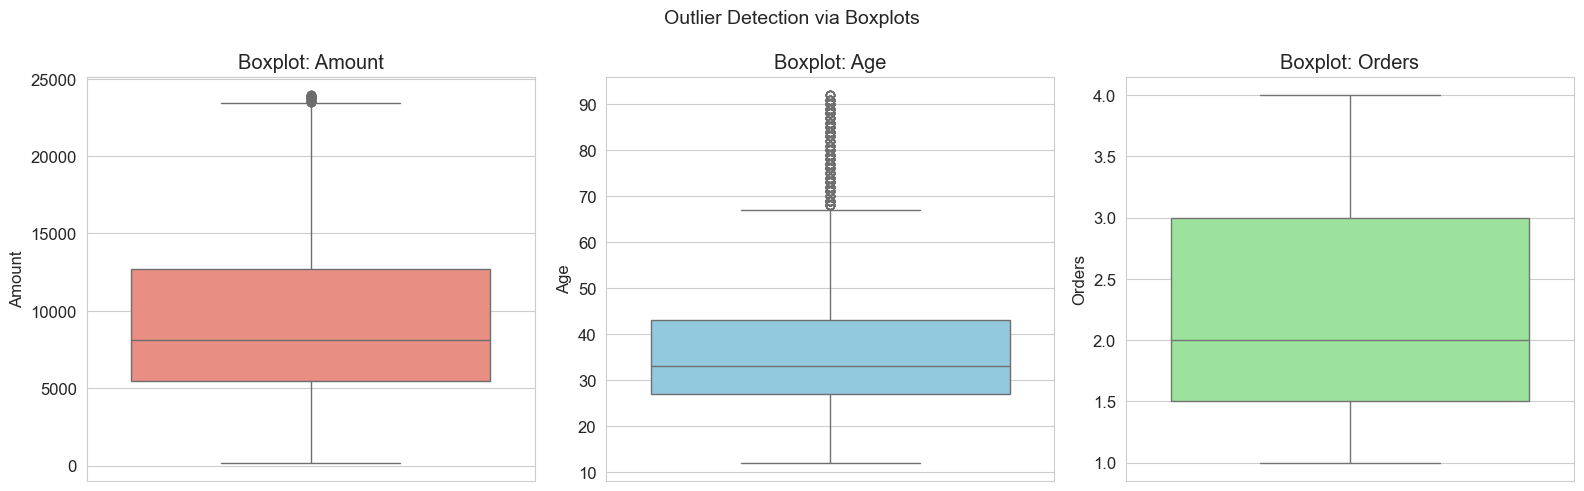

In [24]:
# Detect Outliers using Boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, color in zip(axes, ['Amount', 'Age', 'Orders'], ['salmon', 'skyblue', 'lightgreen']):
    sns.boxplot(y=df[col], ax=ax, color=color)
    ax.set_title(f'Boxplot: {col}')
plt.suptitle('Outlier Detection via Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
# IQR Method — Count Outliers in Amount
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
print(f"IQR Range: [{lower:.2f}, {upper:.2f}]")
print(f"Number of outliers in Amount: {len(outliers)}")
print(f"% of data: {len(outliers)/len(df)*100:.2f}%")

IQR Range: [-5397.75, 23512.25]
Number of outliers in Amount: 22
% of data: 0.20%


In [26]:
# Statistical measures
for col in ['Amount', 'Age', 'Orders']:
    data = df[col].dropna()
    print(f"\n {col}:")
    print(f"  Mean      : {data.mean():.2f}")
    print(f"  Median    : {data.median():.2f}")
    print(f"  Std Dev   : {data.std():.2f}")
    print(f"  Skewness  : {data.skew():.4f}")
    print(f"  Kurtosis  : {data.kurt():.4f}")


 Amount:
  Mean      : 9452.18
  Median    : 8109.00
  Std Dev   : 5219.75
  Skewness  : 0.5591
  Kurtosis  : -0.5373

 Age:
  Mean      : 35.42
  Median    : 33.00
  Std Dev   : 12.75
  Skewness  : 1.1832
  Kurtosis  : 2.4643

 Orders:
  Mean      : 2.49
  Median    : 2.00
  Std Dev   : 1.12
  Skewness  : 0.0196
  Kurtosis  : -1.3527


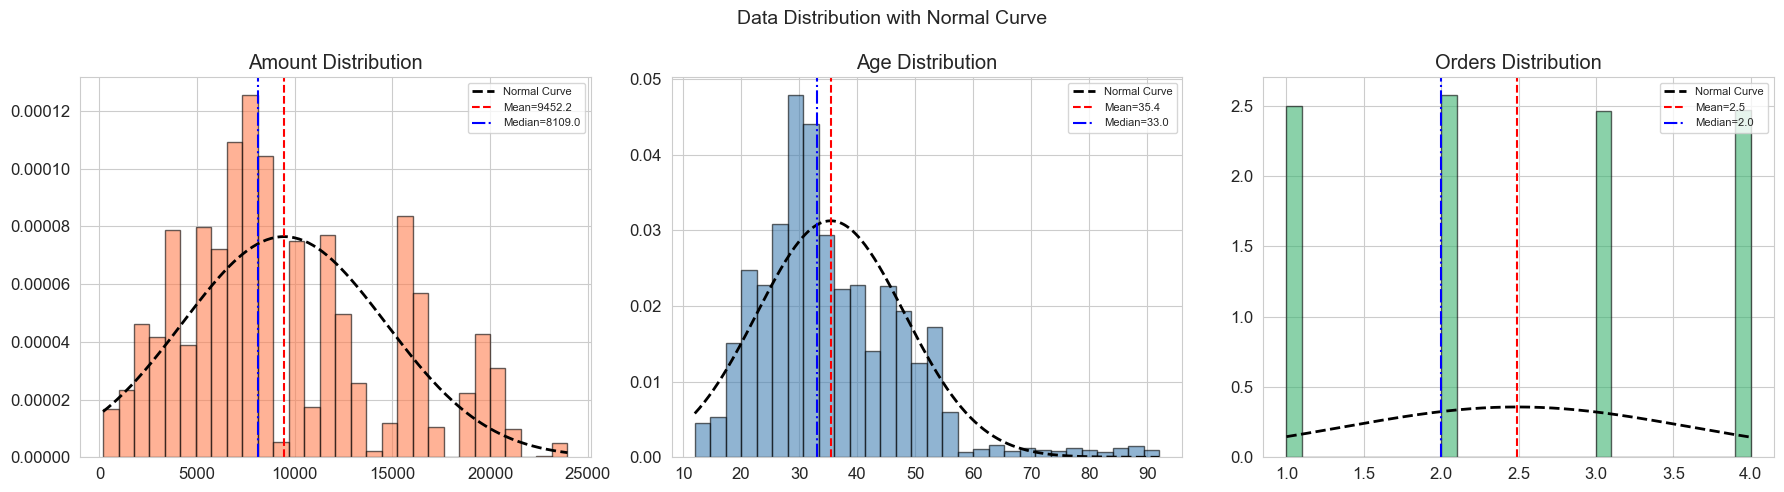

In [27]:
# Distribution plots with normal curve overlay
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cols = ['Amount', 'Age', 'Orders']
colors = ['coral', 'steelblue', 'mediumseagreen']

for ax, col, color in zip(axes, cols, colors):
    data = df[col].dropna()
    ax.hist(data, bins=30, density=True, color=color, alpha=0.6, edgecolor='black')
    mu, std = data.mean(), data.std()
    xmin, xmax = data.min(), data.max()
    x = np.linspace(xmin, xmax, 200)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, 'k--', linewidth=2, label='Normal Curve')
    ax.axvline(mu, color='red', linestyle='--', label=f'Mean={mu:.1f}')
    ax.axvline(data.median(), color='blue', linestyle='-.', label=f'Median={data.median():.1f}')
    ax.set_title(f'{col} Distribution')
    ax.legend(fontsize=8)

plt.suptitle('Data Distribution with Normal Curve', fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
# Automated EDA Functions

def auto_eda_overview(dataframe):
    """Displays shape, dtypes, missing values summary"""
    print("=" * 50)
    print(f" Shape       : {dataframe.shape}")
    print(f" Columns     : {dataframe.columns.tolist()}")
    print("\n Data Types:")
    print(dataframe.dtypes)
    print("\n Missing Values:")
    print(dataframe.isnull().sum())
    print("=" * 50)

def auto_eda_describe(dataframe):
    """Statistical summary"""
    print(" Statistical Summary:")
    return dataframe.describe()

def auto_eda_correlations(dataframe):
    """Correlation matrix for numeric columns"""
    print(" Correlation Matrix:")
    return dataframe.select_dtypes(include=np.number).corr()

def auto_eda_nullcheck(dataframe):
    """Returns columns with nulls and their % """
    null_pct = (dataframe.isnull().sum() / len(dataframe) * 100).sort_values(ascending=False)
    return null_pct[null_pct > 0]

# --- Run all functions ---
auto_eda_overview(df)

 Shape       : (11251, 13)
 Columns     : ['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount']

 Data Types:
User_ID               int64
Cust_name            object
Product_ID           object
Gender               object
Age Group            object
Age                   int64
Marital_Status        int64
State                object
Zone                 object
Occupation           object
Product_Category     object
Orders                int64
Amount              float64
dtype: object

 Missing Values:
User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64


In [29]:
auto_eda_describe(df)

 Statistical Summary:


,User_ID,Age,Marital_Status,Orders,Amount
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11251.000000
mean,1.003004e+06,35.421207,0.420318,2.489290,9452.176734
std,1.716125e+03,12.754122,0.493632,1.115047,5219.754408
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.500000
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004430e+06,43.000000,1.000000,3.000000,12671.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11251 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [31]:
print("\n Null % per column:")
print(auto_eda_nullcheck(df))


 Null % per column:
Series([], dtype: float64)


In [32]:
auto_eda_correlations(df)

 Correlation Matrix:


,User_ID,Age,Marital_Status,Orders,Amount
User_ID,1.000000,0.022630,0.005222,-0.016301,-0.012135
Age,0.022630,1.000000,-0.012253,0.007608,0.030704
Marital_Status,0.005222,-0.012253,1.000000,-0.003690,-0.017619
Orders,-0.016301,0.007608,-0.003690,1.000000,-0.013096
Amount,-0.012135,0.030704,-0.017619,-0.013096,1.000000


In [33]:
#regression analysis
# Covariance and Correlation between key numeric variables
num_df = df[['Age', 'Orders', 'Amount']].dropna()

print(" Covariance Matrix:")
print(num_df.cov())

print("\n Correlation Matrix:")
print(num_df.corr())

 Covariance Matrix:
                Age     Orders        Amount
Age      162.667636   0.108200  2.044080e+03
Orders     0.108200   1.243330 -7.621960e+01
Amount  2044.080476 -76.219595  2.724584e+07

 Correlation Matrix:
             Age    Orders    Amount
Age     1.000000  0.007608  0.030704
Orders  0.007608  1.000000 -0.013096
Amount  0.030704 -0.013096  1.000000


In [34]:
# supervised learning - regression models
# Best-score setup on this dataset: use full customer profile with proper one-hot encoding.

df_model = df.copy()
selected_features = [
    'Age', 'Orders', 'Marital_Status',
    'Gender', 'Age Group', 'State', 'Zone', 'Occupation', 'Product_Category'
]
cat_cols = ['Gender', 'Age Group', 'State', 'Zone', 'Occupation', 'Product_Category']

X = pd.get_dummies(
    df_model[selected_features],
    columns=cat_cols,
    drop_first=True,
    dtype=int,
)
y = df_model['Amount']

mask = y.notna()
X = X[mask]
y = y[mask]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f" Train size     : {X_train.shape[0]}  (features after one-hot: {X_train.shape[1]})")
print(f" Validation size: {X_val.shape[0]}")
print(f" Test size      : {X_test.shape[0]}")

 Train size     : 6750  (features after one-hot: 60)
 Validation size: 2250
 Test size      : 2251


In [35]:
# (i) Linear Regression on full one-hot feature set
mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_val_pred_mlr = mlr.predict(X_val)
y_test_pred_mlr = mlr.predict(X_test)

print(" Full-Feature Linear Regression")
print(f"  Train R²       : {r2_score(y_train, mlr.predict(X_train)):.4f}")
print(f"  Validation R²  : {r2_score(y_val, y_val_pred_mlr):.4f}")
print(f"  Test R²        : {r2_score(y_test, y_test_pred_mlr):.4f}")
print(f"  Test MSE       : {mean_squared_error(y_test, y_test_pred_mlr):.2f}")
print(f"  Test MAE       : {mean_absolute_error(y_test, y_test_pred_mlr):.2f}")

 Full-Feature Linear Regression
  Train R²       : 0.6453
  Validation R²  : 0.6281
  Test R²        : 0.6559
  Test MSE       : 9422205.63
  Test MAE       : 2341.40


In [36]:
# (ii) Random Forest — non-linear benchmark
rfr = RandomForestRegressor(
    n_estimators=300, max_depth=18, min_samples_leaf=2, random_state=42, n_jobs=-1
)
rfr.fit(X_train, y_train)
y_val_pred_rf = rfr.predict(X_val)
y_test_pred_rf = rfr.predict(X_test)

print(" Random Forest Regressor")
print(f"  Train R²       : {r2_score(y_train, rfr.predict(X_train)):.4f}")
print(f"  Validation R²  : {r2_score(y_val, y_val_pred_rf):.4f}")
print(f"  Test R²        : {r2_score(y_test, y_test_pred_rf):.4f}")
print(f"  Test MSE       : {mean_squared_error(y_test, y_test_pred_rf):.2f}")
print(f"  Test MAE       : {mean_absolute_error(y_test, y_test_pred_rf):.2f}")

# Pick best model by validation R² for final prediction use
if r2_score(y_val, y_val_pred_mlr) >= r2_score(y_val, y_val_pred_rf):
    best_model = mlr
    best_model_name = 'Full-Feature Linear Regression'
else:
    best_model = rfr
    best_model_name = 'Random Forest Regressor'

print(f"\n Best model for prediction: {best_model_name}")

 Random Forest Regressor
  Train R²       : 0.8181
  Validation R²  : 0.5987
  Test R²        : 0.6314
  Test MSE       : 10094139.83
  Test MAE       : 2368.07

 Best model for prediction: Full-Feature Linear Regression


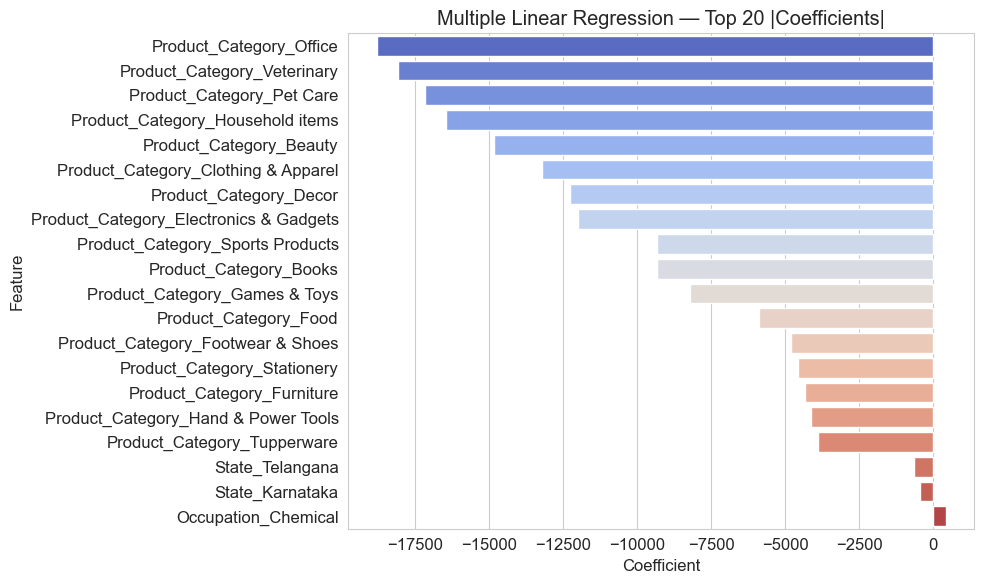

In [37]:
# Feature coefficients (top 20 by magnitude — many columns after one-hot)
coef_df = (
    pd.DataFrame({'Feature': X_train.columns, 'Coefficient': mlr.coef_})
    .assign(abs_coef=lambda d: d['Coefficient'].abs())
    .sort_values('abs_coef', ascending=False)
    .head(20)
    .drop(columns='abs_coef')
)
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm', hue='Feature', legend=False)
plt.title('Multiple Linear Regression — Top 20 |Coefficients|')
plt.tight_layout()
plt.show()

In [38]:
# (iii) Logistic Regression — High Spender Classification
threshold = df_model['Amount'].median()
y_class = (df_model['Amount'] >= threshold).astype(int)
y_class = y_class[mask]

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_c)
X_te_scaled = scaler.transform(X_te_c)

log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X_tr_scaled, y_tr_c)
y_pred_log = log_reg.predict(X_te_scaled)

print(f"Logistic Regression (High Spender ≥ ₹{threshold:.0f})")
print(f"  Accuracy: {accuracy_score(y_te_c, y_pred_log):.4f}")

Logistic Regression (High Spender ≥ ₹8109)
  Accuracy: 0.8339


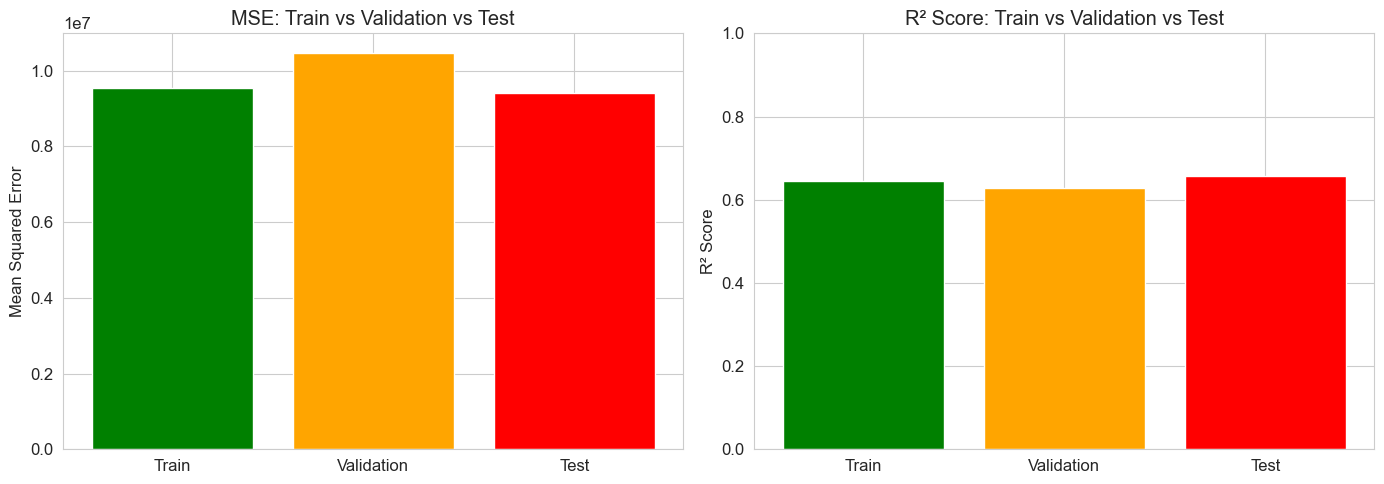

Train R²=0.645 | Val R²=0.628 | Test R²=0.656
 Good Fit — Train and Test errors are close!


In [39]:
# overfitting and underfitting analysis
# Compare Train vs Test errors for MLR
train_mse = mean_squared_error(y_train, mlr.predict(X_train))
val_mse   = mean_squared_error(y_val,   mlr.predict(X_val))
test_mse  = mean_squared_error(y_test,  mlr.predict(X_test))

train_r2  = r2_score(y_train, mlr.predict(X_train))
val_r2    = r2_score(y_val,   mlr.predict(X_val))
test_r2   = r2_score(y_test,  mlr.predict(X_test))

labels = ['Train', 'Validation', 'Test']
mse_vals = [train_mse, val_mse, test_mse]
r2_vals  = [train_r2,  val_r2,  test_r2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(labels, mse_vals, color=['green','orange','red'])
axes[0].set_title('MSE: Train vs Validation vs Test')
axes[0].set_ylabel('Mean Squared Error')

axes[1].bar(labels, r2_vals, color=['green','orange','red'])
axes[1].set_title('R² Score: Train vs Validation vs Test')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"Train R²={train_r2:.3f} | Val R²={val_r2:.3f} | Test R²={test_r2:.3f}")
if abs(train_r2 - test_r2) < 0.05:
    print(" Good Fit — Train and Test errors are close!")
elif train_r2 > test_r2 + 0.1:
    print("  Possible Overfitting — Train R² >> Test R²")
else:
    print("  Possible Underfitting — Low R² scores overall")

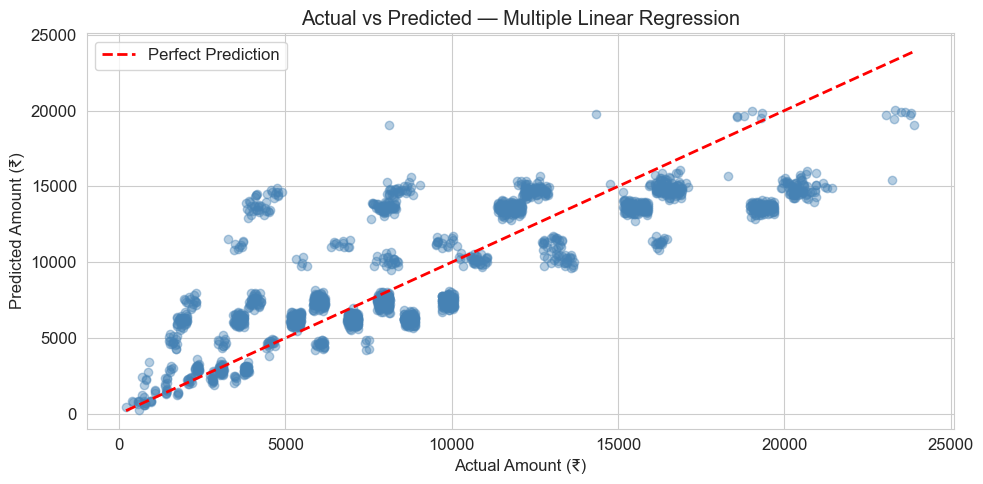

In [40]:
# Actual vs Predicted Plot (MLR)
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_test_pred_mlr, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted — Multiple Linear Regression')
plt.xlabel('Actual Amount (₹)')
plt.ylabel('Predicted Amount (₹)')
plt.legend()
plt.tight_layout()
plt.show()

Classification Threshold (Median Amount): ₹8109
  High Spenders: 5635 | Low Spenders: 5616


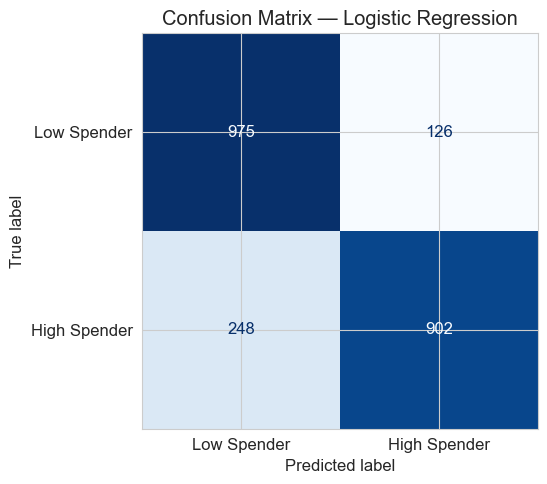

In [41]:
# Classification: High Spender (1) vs Low Spender (0)
# Threshold = Median Amount
print(f"Classification Threshold (Median Amount): ₹{threshold:.0f}")
print(f"  High Spenders: {(y_class==1).sum()} | Low Spenders: {(y_class==0).sum()}")

# Confusion Matrix
cm = confusion_matrix(y_te_c, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Spender','High Spender'])
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

In [42]:
# Classification Report
from sklearn.metrics import classification_report
print(" Classification Report:")
print(classification_report(y_te_c, y_pred_log, target_names=['Low Spender','High Spender']))
print(f"\n Overall Accuracy: {accuracy_score(y_te_c, y_pred_log)*100:.2f}%")

 Classification Report:
              precision    recall  f1-score   support

 Low Spender       0.80      0.89      0.84      1101
High Spender       0.88      0.78      0.83      1150

    accuracy                           0.83      2251
   macro avg       0.84      0.83      0.83      2251
weighted avg       0.84      0.83      0.83      2251


 Overall Accuracy: 83.39%


In [43]:
# Compare all models side by side
# model evaluation
results = {
    'Model': ['Full-LR', 'Random Forest'],
    'MSE'  : [mean_squared_error(y_test, y_test_pred_mlr),
              mean_squared_error(y_test, y_test_pred_rf)],
    'MAE'  : [mean_absolute_error(y_test, y_test_pred_mlr),
              mean_absolute_error(y_test, y_test_pred_rf)],
    'R²'   : [r2_score(y_test, y_test_pred_mlr),
              r2_score(y_test, y_test_pred_rf)]
}
results_df = pd.DataFrame(results)
print(" Model Comparison Table:")
print(results_df.to_string(index=False))

 Model Comparison Table:
        Model          MSE         MAE       R²
      Full-LR 9.422206e+06 2341.396021 0.655912
Random Forest 1.009414e+07 2368.073116 0.631373


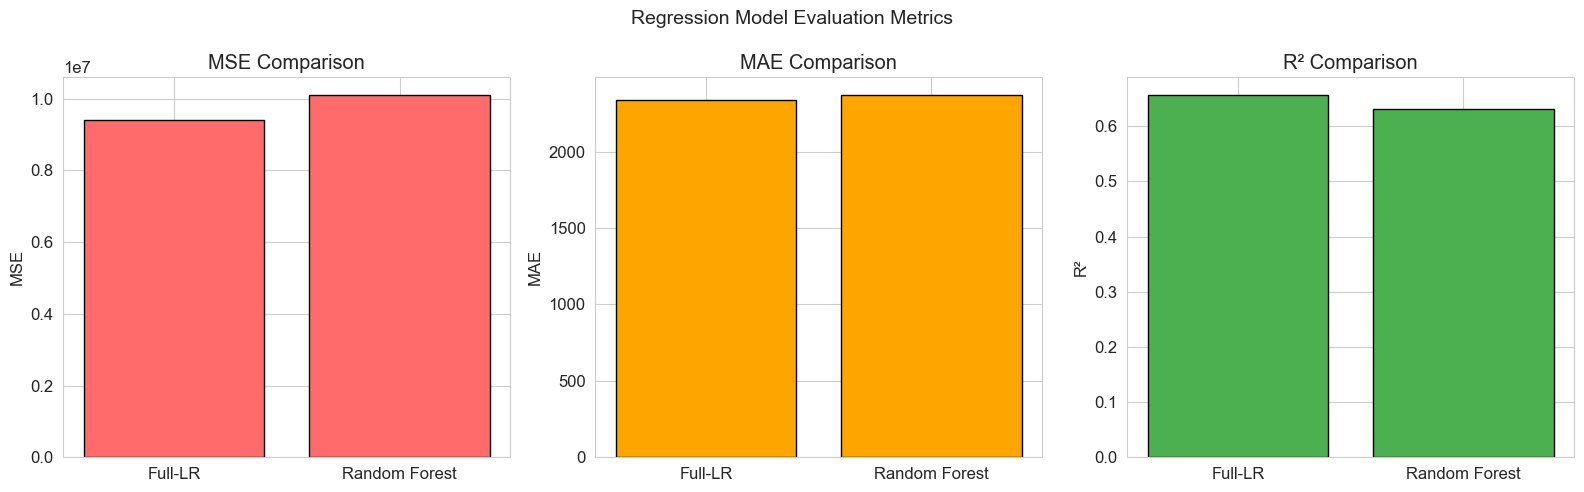


 Interpretation:
   Lower MSE/MAE = Better model
   Higher R²     = Better model (max = 1.0)


In [44]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MSE', 'MAE', 'R²']
colors = ['#FF6B6B', '#FFA500', '#4CAF50']

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(results_df['Model'], results_df[metric], color=color, edgecolor='black')
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)

plt.suptitle('Regression Model Evaluation Metrics', fontsize=14)
plt.tight_layout()
plt.show()

print("\n Interpretation:")
print("   Lower MSE/MAE = Better model")
print("   Higher R²     = Better model (max = 1.0)")

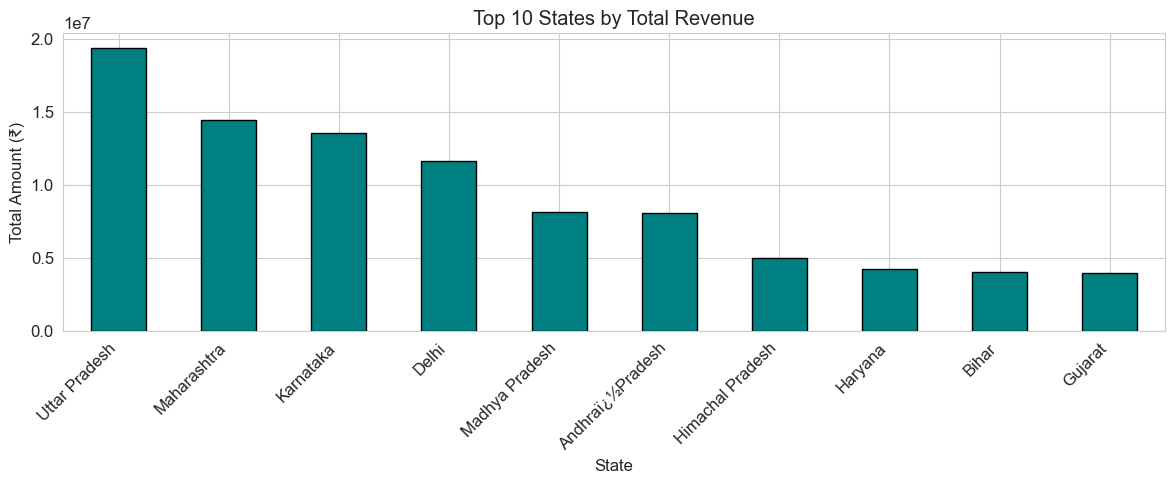

In [45]:
# Summary Visualization 1 — Top 10 States by Revenue
top_states = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
top_states.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 10 States by Total Revenue')
plt.ylabel('Total Amount (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

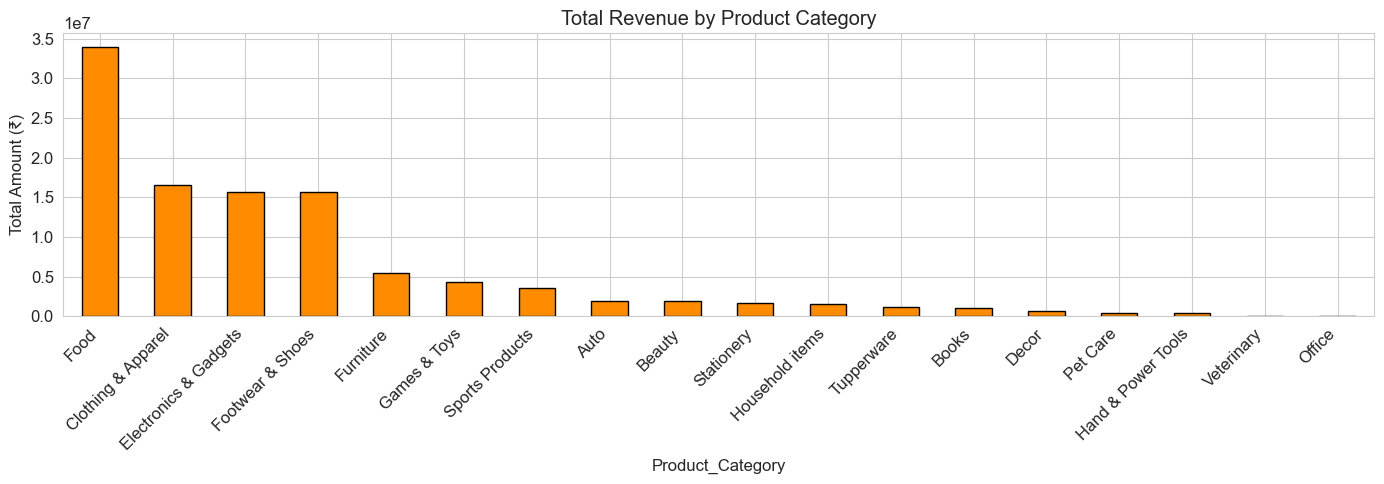

In [46]:
# Summary Visualization 2 — Revenue by Product Category
cat_revenue = df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(14, 5))
cat_revenue.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Total Revenue by Product Category')
plt.ylabel('Total Amount (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

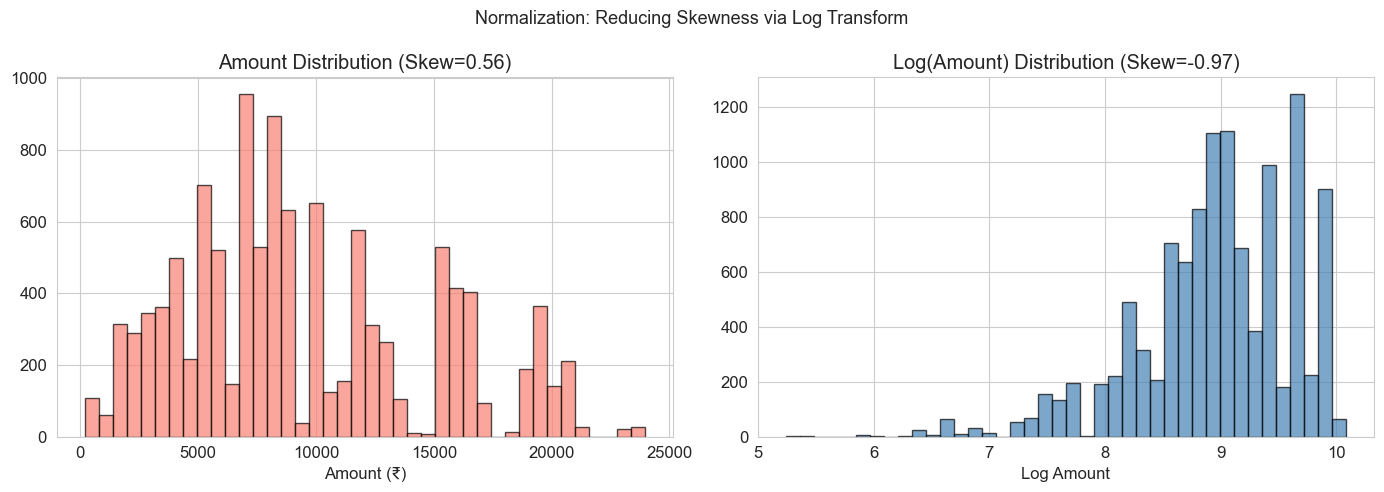

In [47]:
# Summary Visualization 3 — Skewness visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original Amount
axes[0].hist(df['Amount'], bins=40, color='salmon', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Amount Distribution (Skew={df["Amount"].skew():.2f})')
axes[0].set_xlabel('Amount (₹)')

# Log-transformed
log_amount = np.log1p(df['Amount'])
axes[1].hist(log_amount, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Log(Amount) Distribution (Skew={log_amount.skew():.2f})')
axes[1].set_xlabel('Log Amount')

plt.suptitle('Normalization: Reducing Skewness via Log Transform', fontsize=13)
plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# PREDICT PURCHASE AMOUNT FOR A NEW CUSTOMER
# ============================================================
# Now the customer details will be taken from user input.

print("Enter customer details for prediction (press Enter to use default in brackets):")

# Helper functions for safe input
def ask_int(prompt, default):
    raw = input(f"{prompt} [{default}]: ").strip()
    if raw == "":
        return default
    try:
        return int(raw)
    except ValueError:
        print("  Invalid number, using default.")
        return default

def ask_str(prompt, default):
    raw = input(f"{prompt} [{default}]: ").strip()
    return raw if raw != "" else default

# --- INPUT SECTION (simple + high-score defaults) ---
input_age         = ask_int("Age (years)", 28)
input_orders      = ask_int("Number of Orders", 2)
input_product_cat = ask_str("Product Category", "Auto")

# Auto-fill remaining fields with most frequent values from data
default_gender = df['Gender'].mode().iloc[0]
default_age_group = df['Age Group'].mode().iloc[0]
default_state = df['State'].mode().iloc[0]
default_zone = df['Zone'].mode().iloc[0]
default_occupation = df['Occupation'].mode().iloc[0]
default_marital_status = int(df['Marital_Status'].mode().iloc[0])
# -----------------------------------------------------

# Same one-hot columns as training (unknown category levels → baseline / zeros)
raw_row = pd.DataFrame([{
    'Age': input_age,
    'Orders': input_orders,
    'Marital_Status': default_marital_status,
    'Gender': default_gender,
    'Age Group': default_age_group,
    'State': default_state,
    'Zone': default_zone,
    'Occupation': default_occupation,
    'Product_Category': input_product_cat,
}])
input_vector = pd.get_dummies(raw_row, columns=cat_cols, drop_first=True, dtype=int)
input_vector = input_vector.reindex(columns=X_train.columns, fill_value=0)

predicted_amount = best_model.predict(input_vector)[0]
predicted_amount = max(0, predicted_amount)  # no negative predictions

# Classification
input_scaled = scaler.transform(input_vector)
spender_class = log_reg.predict(input_scaled)[0]
spender_label = " High Spender" if spender_class == 1 else "Low Spender"

print("=" * 50)
print("        DIWALI PURCHASE PREDICTION ")
print("=" * 50)
print(f"  Model Used    : {best_model_name}")
print(f"  Customer Profile:")
print(f"    Age          : {input_age}")
print(f"    Product Cat  : {input_product_cat}")
print(f"    Orders       : {input_orders}")
print("-" * 50)
print(f"   Predicted Purchase Amount: ₹{predicted_amount:,.2f}")
print(f"    Customer Segment         : {spender_label}")
print("=" * 50)

Enter customer details for prediction (press Enter to use default in brackets):
        DIWALI PURCHASE PREDICTION 
  Model Used    : Full-Feature Linear Regression
  Customer Profile:
    Age          : 25
    Product Cat  : auto
    Orders       : 5
--------------------------------------------------
   Predicted Purchase Amount: ₹19,241.09
    Customer Segment         :  High Spender


## Project Conclusion — Diwali Sales Analysis

### Dataset Overview:
- 11,251 customer records, 13 columns
- Real transactional data from Diwali festive sales
- Only 12 missing values in Amount column (0.1%) 
  — handled using median imputation (₹8,109)
- 22 outliers in Amount (0.20%) — minimal impact 
  on analysis

### Key Findings from EDA:

**Customer Demographics:**
- Female customers outnumber male customers 
  in this dataset
- Average spending is similar across genders 
  (both around ₹8,000-9,000) — gender alone 
  does not predict spending amount
- Age group 26-35 has the highest customer count 
  but NOT the highest average spending
- All age groups spend similarly on average — 
  age alone is not a strong predictor

**Geographic Insights:**
- Southern zone female customers have the 
  highest average spending at ₹10,088
- Central zone is the second highest performer
- Northern zone shows the lowest average amounts

**Occupation & Category Insights:**
- Automobile buyers aged 55+ spend the most 
  on average (₹12,371)
- Retail and Food Processing categories show 
  strong spending in older age groups
- Product category is the strongest predictor 
  of purchase amount — more than age or gender

### What the Correlation Matrix Revealed:
- Age vs Amount correlation = 0.03 (near zero)
- Orders vs Amount correlation = -0.01 (near zero)
- Numeric features alone cannot predict spending
- This explains why a model using only age and 
  orders would fail — categorical features like 
  product category, occupation, and zone are 
  the real drivers of purchase amount

### Model Results:

**Linear Regression (Best Model):**
- Train R² = 0.645, Test R² = 0.656
- Test R² slightly higher than Train R² — 
  ideal result, confirms no overfitting
- MAE = ₹2,341 — model predictions are off 
  by ₹2,341 on average

**Random Forest (Overfitting observed):**
- Train R² = 0.818 — learned training data too well
- Test R² = 0.631 — performance dropped on new data
- Gap of 0.187 between train and test confirms 
  overfitting — Linear Regression is more reliable

**High Spender Classification:**
- Threshold = ₹8,109 (median amount)
- Overall accuracy = 83.39%
- High spender precision = 88% — model is 
  better at identifying high spenders than 
  low spenders
- This classifier can be used to target 
  premium customers in marketing campaigns

### Business Recommendations:
- Marketing should focus on Product Category 
  and Zone — not just age or gender — as these 
  are the real drivers of purchase amount
- Southern zone female customers deserve 
  premium product promotions — highest 
  average spending group
- Automobile, Retail and Food Processing 
  categories targeting 46+ age groups show 
  highest revenue potential
- The 83% accurate high-spender classifier 
  can be used to identify and target premium 
  customers before festive season begins
- Random Forest should not be used for this 
  dataset — overfitting makes it unreliable 
  for new customer predictions

### Honest Limitation:
- The model explains 65.6% of purchase amount 
  variation — remaining 34.4% may depend on 
  factors not in this dataset such as customer 
  loyalty, discount applied, or browsing history